# Deep Research Agent — `create_goap_agent` + tracing + history in Store

A Tier 3 tutorial that GOAPifies the
[deep_research example](https://github.com/langchain-ai/deepagents/tree/main/examples/deep_research)
from LangChain's `deepagents`. The original runs an orchestrator loop
that calls `write_todos`, delegates to a research sub-agent that calls
Tavily, then writes the final report to a mock filesystem. Here we
translate the same five-step workflow into a LangGOAP plan driven by
the Layer A one-liner `create_goap_agent`, with a hermetic in-memory
corpus standing in for Tavily so the notebook runs without network
access or API keys.

This notebook spotlights five LangGOAP features at once:

1. **`create_goap_agent`** — the "most prebuilt" Layer A on-ramp. Wrap
   ordinary `@tool` functions, pass explicit preconditions/effects,
   and get back a compiled LangGraph graph with zero manual
   `ActionSpec` plumbing.
2. **`PlanningTracer` observability** — a `LoggingTracer` captures
   every plan/replan/goal-achieved event so you can see the whole
   orchestrator loop in human-readable form.
3. **`StoreExecutionHistory` persistence** — a LangGraph `InMemoryStore`
   records every successful run as an `ExecutionRecord`; diagnostics
   can query the history by goal hash across multiple invocations.
4. **Multi-step replanning** — the cheap `search_broad_corpus` tool
   raises `RateLimitError` against a rate-limited workspace. The
   executor blacklists it and the planner's fallback re-routes
   through the more expensive `search_deep_corpus` on the next pass.
5. **Natural-language intake** — `GoapGraph.invoke_nl` drives the
   same end-to-end run from a plain English research question.

Everything is hermetic: no shell commands, no real web traffic, no
external dependencies. The whole tutorial is exercised by
`tests/integration/test_deep_research_agent.py` and this notebook
imports the exact same helpers the test imports, so what you see
below is identical to what CI verifies on every commit.

In [1]:
import logging

# search_broad_corpus deliberately raises on the first pass so the
# planner can replan; silence the expected warning so the notebook
# output stays readable.
logging.getLogger('langgoap').setLevel(logging.ERROR)

from tutorial_examples.data.deep_research_instance import (
    CORPUS,
    EXPECTED_BROAD_FINDING_IDS,
    EXPECTED_DEEP_FINDING_IDS,
    EXPECTED_TOPICS,
    MIN_REPORT_CITATIONS,
    RESEARCH_REQUEST,
)
from tutorial_examples.deep_research_agent import (
    ResearchWorkspace,
    deep_research_costs,
    deep_research_effects,
    deep_research_goal,
    deep_research_preconditions,
    deep_research_start,
    deep_research_tools,
)

print(f'Corpus size       : {len(CORPUS)} documents')
print(f'Research request  : {RESEARCH_REQUEST}')
print(f'Minimum citations : {MIN_REPORT_CITATIONS}')

Corpus size       : 10 documents
Research request  : How do modern AI agent frameworks combine retrieval-augmented generation with transformers?
Minimum citations : 3


## 1. The corpus and the expected decomposition

`CORPUS` is a ten-document slice of AI/ML papers, each tagged with a
small topic set. The decomposition step scans the request against the
corpus's tag vocabulary and records each matching tag in corpus order
— a deterministic substitute for the LLM-driven `write_todos` step
in the `deepagents` original.

In [2]:
for doc in CORPUS:
    tags = ','.join(doc.tags)
    print(f'  {doc.id:<7s}  {doc.title[:44]:<44s}  [{tags}]')

print()
print(f'Expected topics from decomposition: {list(EXPECTED_TOPICS)}')

  doc_1    Attention Is All You Need                     [transformers,attention,deep_learning]
  doc_2    The Illustrated Transformer                   [transformers,attention,education]
  doc_3    Retrieval-Augmented Generation for Knowledge  [retrieval_augmented_generation,knowledge_base,nlp]
  doc_4    Dense Passage Retrieval for Open-Domain QA    [retrieval_augmented_generation,dense_retrieval,nlp]
  doc_5    ReAct: Synergizing Reasoning and Acting in L  [agent_frameworks,reasoning,tool_use]
  doc_6    LangGraph: Stateful, Multi-Actor LLM Applica  [agent_frameworks,orchestration,langchain]
  doc_7    Toolformer: Language Models Can Teach Themse  [agent_frameworks,tool_use,self_supervision]
  doc_8    Goal-Oriented Action Planning for Games       [goap,planning,game_ai]
  doc_9    Reinforcement Learning from Human Feedback    [alignment,rlhf,instruction_tuning]
  doc_10   Constitutional AI: Harmlessness from AI Feed  [alignment,self_critique,rlhf]

Expected topics from decompositio

## 2. The tools, preconditions, effects, and costs

Five tools model the orchestrator loop:

| tool | analogue in `deepagents` | cost |
| --- | --- | --- |
| `save_research_request`  | `write_file('/research_request.md')` | 1 |
| `decompose_topics`       | `write_todos`                         | 1 |
| `search_broad_corpus`    | cheap `tavily_search`                 | 2 |
| `search_deep_corpus`     | exhaustive `tavily_search`            | 5 |
| `synthesize_report`      | `write_file('/final_report.md')`      | 1 |

Every tool is an ordinary LangChain `@tool` function that closes over
a shared `ResearchWorkspace` object. The workspace holds the real
corpus, the gathered findings, and the final report; GOAP only tracks
the four boolean phase flags that drive planning
(`request_saved`, `topics_planned`, `findings_gathered`,
`report_written`). That clean separation lets Layer A's generic
`goapify_tool` wrapper stay completely content-agnostic.

**Why every tool declares a `query: str` parameter.** Layer B's
`goapify_tool` wrapper binds tool arguments from the current
world-state dict by *name*: for every field in a tool's
`args_schema` it reads the matching key from `state['world_state']`
and forwards the value. The research request sits on that world
state under the key `'query'`, so each of the five tools declares
`query: str` to receive it — even `decompose_topics`,
`search_broad_corpus`, `search_deep_corpus`, and `synthesize_report`,
which ignore the value and read the previously-saved request off the
workspace instead. You will see a `del query` on the first line of
those four tools in `deep_research_agent.py`; that is an
intentional acknowledgement of the binding constraint, not dead
code. The upside is that Layer A never has to parse docstrings or
guess at argument bindings to wire a tool into the planner.

In [3]:
workspace = ResearchWorkspace(rate_limit_active=False)
tools = deep_research_tools(workspace)

pre = deep_research_preconditions()
eff = deep_research_effects()
costs = deep_research_costs()
for t in tools:
    p = pre.get(t.name, {})
    e = eff.get(t.name, {})
    c = costs.get(t.name, 1.0)
    print(f'  {t.name:<24s}  cost={c}  pre={p}  eff={e}')

  save_research_request     cost=1.0  pre={'request_saved': False}  eff={'request_saved': True}
  decompose_topics          cost=1.0  pre={'request_saved': True, 'topics_planned': False}  eff={'topics_planned': True}
  search_broad_corpus       cost=2.0  pre={'topics_planned': True, 'findings_gathered': False}  eff={'findings_gathered': True}
  search_deep_corpus        cost=5.0  pre={'topics_planned': True, 'findings_gathered': False}  eff={'findings_gathered': True}
  synthesize_report         cost=1.0  pre={'findings_gathered': True, 'report_written': False}  eff={'report_written': True}


### GOAP Execution Graph

The planner discovers a plan, the executor runs each action, and the
observer checks progress — replanning automatically if something fails.

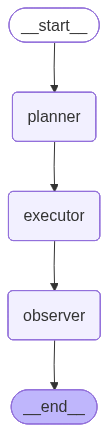

In [4]:
from IPython.display import Image, display
from langgoap import GoapGraph
from langgoap.integrations import goapify_tool

graph_actions = [
    goapify_tool(
        t,
        preconditions=pre.get(t.name),
        effects=eff.get(t.name),
        cost=costs.get(t.name, 1.0),
    )
    for t in tools
]
display(Image(GoapGraph(actions=graph_actions).compile().get_graph().draw_mermaid_png()))

## 3. The Layer A one-liner: `create_goap_agent`

`create_goap_agent` accepts the list of tools, a `GoalSpec`, and the
maps of preconditions/effects/costs. It wraps each tool via Layer B's
`goapify_tool` and returns a `CompiledStateGraph` ready for
`.invoke()` — no manual `ActionSpec` construction, no explicit
`GoapGraph` builder. The shape is deliberately the same as
`langgraph.prebuilt.create_react_agent` so LangGraph users feel at
home immediately.

The happy path below uses `rate_limit_active=False`, so the cheap
`search_broad_corpus` path fires end-to-end:

In [5]:
from langgoap import create_goap_agent

agent = create_goap_agent(
    tools=tools,
    goal=deep_research_goal(),
    preconditions=pre,
    effects=eff,
    costs=costs,
)

result = agent.invoke({
    'goal': deep_research_goal(),
    'world_state': deep_research_start(),
})

print(f'Status       : {result["status"]}')
print(f'Replans      : {result["replan_count"]}')
print(f'Blacklisted  : {result.get("blacklisted_actions", [])}')
success_names = [h.action_name for h in result['execution_history'] if h.success]
print(f'Succeeded    : {success_names}')

Status       : goal_achieved
Replans      : 0
Blacklisted  : []
Succeeded    : ['save_research_request', 'decompose_topics', 'search_broad_corpus', 'synthesize_report']


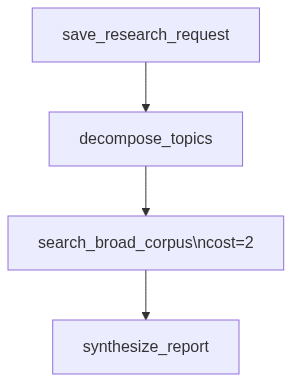

In [6]:
from langchain_core.runnables.graph_mermaid import draw_mermaid_png as _draw_png
from langgoap.viz.mermaid import render_mermaid

display(Image(_draw_png(render_mermaid(result["plan"]))))

With the workspace wide open A\* picks the cheapest chain
(`save → decompose → broad → synthesize`, total cost 5.0) and the
run completes in one planning pass. The workspace now holds the
gathered findings and the synthesized report:

In [7]:
print(f'Topics        : {workspace.topics}')
print(f'Findings      : {[f.id for f in workspace.findings]}')
print()
print('Report citations:')
for citation in workspace.report['citations']:
    print(f'  - {citation["title"][:60]:<60s}  {citation["url"]}')

Topics        : ['transformers', 'retrieval_augmented_generation', 'agent_frameworks']
Findings      : ['doc_1', 'doc_3', 'doc_5']

Report citations:
  - Attention Is All You Need                                     https://arxiv.org/abs/1706.03762
  - Retrieval-Augmented Generation for Knowledge-Intensive NLP    https://arxiv.org/abs/2005.11401
  - ReAct: Synergizing Reasoning and Acting in Language Models    https://arxiv.org/abs/2210.03629


## 4. Replanning after a rate-limit error

Flip the workspace to `rate_limit_active=True` and the cheap broad
search raises `RateLimitError` on its first invocation. The executor
catches the exception, blacklists the action, and the planner's
fallback route re-plans through the costlier `search_deep_corpus`
tool — exactly the blacklist + replan dance that Tier 2's
`vulnerability_scanner` tutorial demonstrates, now wired end-to-end
through Layer A.

In [8]:
rate_limited_workspace = ResearchWorkspace(rate_limit_active=True)
rate_limited_agent = create_goap_agent(
    tools=deep_research_tools(rate_limited_workspace),
    goal=deep_research_goal(),
    preconditions=pre,
    effects=eff,
    costs=costs,
)

result = rate_limited_agent.invoke({
    'goal': deep_research_goal(),
    'world_state': deep_research_start(),
})

print(f'Status       : {result["status"]}')
print(f'Replans      : {result["replan_count"]}')
print(f'Blacklisted  : {result.get("blacklisted_actions", [])}')
print()
print('Execution history:')
for h in result['execution_history']:
    outcome = 'ok    ' if h.success else 'failed'
    err = f' ({h.error})' if h.error else ''
    print(f'  {outcome}  {h.action_name}{err}')

Status       : goal_achieved
Replans      : 1
Blacklisted  : ['search_broad_corpus']

Execution history:
  ok      save_research_request
  ok      decompose_topics
  failed  search_broad_corpus (rate limit exceeded on broad corpus search)
  ok      search_deep_corpus
  ok      synthesize_report


Two telltale signs confirm the replan happened:

- `search_broad_corpus` appears in both `blacklisted_actions` and the
  execution history with `success=False`.
- The final successful chain used `search_deep_corpus` instead, and
  the workspace now holds the deep-search findings
  (every document whose tag set intersects any topic).

In [9]:
print(f'Deep findings: {[f.id for f in rate_limited_workspace.findings]}')
assert tuple(f.id for f in rate_limited_workspace.findings) == EXPECTED_DEEP_FINDING_IDS

Deep findings: ['doc_1', 'doc_2', 'doc_3', 'doc_4', 'doc_5', 'doc_6', 'doc_7']


## 5. Observability — `LoggingTracer`

A `PlanningTracer` is a tiny Protocol with one hook per planning
event: `on_plan_start`, `on_plan_complete`, `on_action_start`,
`on_action_complete`, `on_replan`, `on_goal_achieved`, plus their
async variants. LangGOAP ships `NullTracer`, `LoggingTracer`, and
`MultiTracer`; you pass one to `GoapGraph(..., tracer=tracer)` and
every event is routed through it.

`LoggingTracer` sends everything to the `langgoap.tracing` logger.
Below we capture that logger to a `StringIO` buffer so the notebook
can display what it would normally stream to stderr.

In [10]:
import io

from langgoap import GoapGraph, LoggingTracer
from langgoap.integrations import goapify_tool

# Route langgoap.tracing INFO logs to a StringIO buffer for display.
buffer = io.StringIO()
handler = logging.StreamHandler(buffer)
handler.setFormatter(logging.Formatter('%(message)s'))
tracing_logger = logging.getLogger('langgoap.tracing')
tracing_logger.addHandler(handler)
tracing_logger.setLevel(logging.INFO)

traced_workspace = ResearchWorkspace(rate_limit_active=True)
traced_actions = [
    goapify_tool(
        t,
        preconditions=pre.get(t.name),
        effects=eff.get(t.name),
        cost=costs.get(t.name, 1.0),
    )
    for t in deep_research_tools(traced_workspace)
]

traced_graph = GoapGraph(actions=traced_actions, tracer=LoggingTracer())
traced_result = traced_graph.invoke(
    goal=deep_research_goal(),
    world_state=deep_research_start(),
)
print(f'Status       : {traced_result["status"]}')
print()
print('Tracer log:')
for line in buffer.getvalue().splitlines():
    print(f'  {line[:100]}')

tracing_logger.removeHandler(handler)

Status       : goal_achieved

Tracer log:
  plan_start strategy=AStar goal=GoalSpec(conditions={'report_written': True})
  plan_complete duration_ms=0.08 plan=Plan(actions=['save_research_request', 'decompose_topics', 'sear
  action_start name=save_research_request
  action_complete result={'world_state': {'query': 'How do modern AI agent frameworks combine retrieva
  action_start name=decompose_topics
  action_complete result={'world_state': {'query': 'How do modern AI agent frameworks combine retrieva
  action_start name=search_broad_corpus
  action_complete result={'status': 'action_failed', 'execution_history': [ActionResult(action_name='s
  plan_start strategy=AStar goal=GoalSpec(conditions={'report_written': True})
  replan reason=action_failed new_plan=Plan(actions=['search_deep_corpus', 'synthesize_report'], total
  action_start name=search_deep_corpus
  action_complete result={'world_state': {'query': 'How do modern AI agent frameworks combine retrieva
  action_start name=synt

## 6. Execution history in a LangGraph Store

`StoreExecutionHistory` persists one `ExecutionRecord` per
successful/failed run into any LangGraph `BaseStore`. Under the
hood it maintains two reverse indexes (by goal hash, by failure
action) using only `get`/`put` — no `search()` calls, so every
`BaseStore` implementation works without configuring an embedder.

We drive three runs through a fresh `InMemoryStore` and then query
the history by the goal hash to see all three records:

In [11]:
from langgraph.store.memory import InMemoryStore

from langgoap import StoreExecutionHistory

store = InMemoryStore()
history = StoreExecutionHistory(store)

# Three independent runs — a mix of happy path and replanning.
for rate_limit in (False, True, False):
    ws = ResearchWorkspace(rate_limit_active=rate_limit)
    history_graph = GoapGraph(
        actions=[
            goapify_tool(
                t,
                preconditions=pre.get(t.name),
                effects=eff.get(t.name),
                cost=costs.get(t.name, 1.0),
            )
            for t in deep_research_tools(ws)
        ],
        history=history,
    )
    history_graph.invoke(
        goal=deep_research_goal(),
        world_state=deep_research_start(),
    )

# Query the store by goal hash using the public helper on
# StoreExecutionHistory — no private symbols required.
goal_hash = history.goal_hash_for(deep_research_goal())
records = history.query_by_goal(goal_hash)
print(f'Goal hash     : {goal_hash}')
print(f'Records found : {len(records)}')
print()
print('Recent runs (newest first):')
for rec in records:
    print(
        f'  {rec.timestamp.isoformat():<32s}  outcome={rec.outcome:<8s}  '
        f'replans={rec.replan_count}  plan={list(rec.plan_actions)}'
    )

Goal hash     : 0d629ccf03cec991
Records found : 3

Recent runs (newest first):
  2026-04-18T13:30:41.265720+00:00  outcome=success   replans=0  plan=['save_research_request', 'decompose_topics', 'search_broad_corpus', 'synthesize_report']
  2026-04-18T13:30:41.256309+00:00  outcome=success   replans=1  plan=['search_deep_corpus', 'synthesize_report']
  2026-04-18T13:30:41.246047+00:00  outcome=success   replans=0  plan=['save_research_request', 'decompose_topics', 'search_broad_corpus', 'synthesize_report']


The store now records three successful runs. A cost-learning system
could query this history on every new invocation to bias A\* against
actions that historically failed — the data model for cost learning
ships in v0.1.0 even though the learning algorithm itself is
deliberately out of scope.

## 7. Natural-language goal intake

As with every Tier 2/3 tutorial, LangGOAP can accept a plain English
research request and turn it into a `GoalSpec` via `GoalInterpreter`.
For a hermetic, runnable notebook we use `FakeStructuredModel` — the
public testing helper that mirrors the `langchain.testing` pattern —
so no real LLM is required.

In [12]:
from langgoap import InterpretedGoal
from langgoap.testing import FakeStructuredModel

nl_workspace = ResearchWorkspace(rate_limit_active=True)
nl_actions = [
    goapify_tool(
        t,
        preconditions=pre.get(t.name),
        effects=eff.get(t.name),
        cost=costs.get(t.name, 1.0),
    )
    for t in deep_research_tools(nl_workspace)
]
llm = FakeStructuredModel(
    response=InterpretedGoal(
        conditions={'report_written': True},
        constraints=[],
        objectives=[],
        reasoning='The operator asked for a written report.',
    ),
)
nl_result = GoapGraph(actions=nl_actions).invoke_nl(
    'Research how modern agent frameworks use RAG with transformers.',
    llm=llm,
    world_state=deep_research_start(),
)
print(f'Status       : {nl_result["status"]}')
print(f'Replans      : {nl_result["replan_count"]}')
print(f'Citations    : {len(nl_workspace.report["citations"])}')

Status       : goal_achieved
Replans      : 1
Citations    : 7


## Summary

Five tools, a hand-curated corpus, and a closed-over workspace are
enough to demonstrate the `deepagents` deep-research loop inside
LangGOAP — with full observability, persistence and NL intake at no
extra cost:

- **Layer A** `create_goap_agent` wraps ordinary `@tool` functions
  into a compiled LangGraph graph with zero manual `ActionSpec`
  plumbing. Preconditions and effects are never LLM-inferred —
  they are passed explicitly so the planner has a sound abstraction.
- **Replanning** routes around the rate-limited cheap search
  without any special-case code: the executor catches the exception,
  the observer blacklists the failing action, and the planner's
  fallback re-plans through the expensive `search_deep_corpus`.
- **`LoggingTracer`** turns every plan/replan/goal-achieved event
  into a log line, and is drop-in compatible with OpenTelemetry or
  LangSmith adapters for production use.
- **`StoreExecutionHistory`** persists run outcomes to any LangGraph
  `BaseStore` using only `get`/`put`, so you can query history by
  goal hash or failing action across multiple sessions.
- **`GoapGraph.invoke_nl`** takes a plain English request and drives
  the same end-to-end loop through `GoalInterpreter` + A\* + the
  blacklist dance, hermetically testable via `FakeStructuredModel`.

The integration test that pins every piece of behavior shown above
lives in `tests/integration/test_deep_research_agent.py`.